In [1]:
!pip install torch tensorflow ultralytics pillow matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.5 MB/s eta 0:00:00a 0:00:01


In [2]:
import torch
import tensorflow as tf
from ultralytics import YOLO
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import shutil
import gc

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# 0. Verificação da GPU

In [3]:
if tf.test.gpu_device_name():
    print("GPU found!")
else:
    print("GPU not found!")
    
print(torch.cuda.is_available())
print(torch.cuda.device_count())

GPU found!
True
1


I0000 00:00:1773263268.803069      55 gpu_device.cc:2019] Created device /device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [11]:
!nvidia-smi

Wed Mar 11 21:16:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P0             38W /  250W |   13571MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [10]:
# Código para, caso a memória cache esteja cheia, esvaziar
gc.collect()
torch.cuda.empty_cache()

# 1. Configurando ambiente de treinamento

In [5]:
%%writefile dataset.yaml

# Configuração do arquivo yaml onde tem os paths e configurações gerais que serão utilizadas
train: /kaggle/input/datasets/nicodenico/microscopia/dataset/images/Train
test: /kaggle/input/datasets/nicodenico/microscopia/dataset/images/Test
val: /kaggle/input/datasets/nicodenico/microscopia/dataset/images/Val

names:
  0: mono_flakes

Overwriting dataset.yaml


# 2. Treinando

Para entender melhor os parâmetros e arquitetura da rede é possível ler a [documentação da Ultralytics](https://docs.ultralytics.com/pt/modes/train/#musgd-optimizer)

In [3]:
model = YOLO("yolov8s-seg.pt")   # pode ser n, s, m, l, x, mas é necessário considerar underfit e overfit com base no modelo

model.train(
    data="/kaggle/working/dataset.yaml",
    rect = False,
    seed = 2026, # Para reprodutibilidade
    imgsz=1024, # comprime a imagem para 1024 x 1024 pixels
    batch= 4,
    epochs=50,
    augment=True, # Ativa vários parâmetros de aumento de dados e hiperparâmetros, possível encontrar na documentação
    degrees=30, # Gira a imagem aleatoriamente em até 15 graus
    fliplr=0.5, # Inverte a imagem horizontalmente com 50% de probabilidade
    flipud=0.5, # Inverte a imagem verticamente com 50% de probabilidade
    save_period = 5, # A cada 5 épocas salva o modelo
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yaml, degrees=30, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train10, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bf975a199d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [ ]:
# Código para, caso o treinamento seja interrompido, voltar a treinar. Importante dado o limite de memória

model = YOLO("/kaggle/working/runs/segment/train9/weights/best.pt")  # caminho contendo os pesos e as épocas etc. (um arquivo .pt)

model.train(
    data="dataset.yaml",
    resume=True
)

In [4]:
# Salvar o modelo
shutil.make_archive("modelo", "zip", "/kaggle/working/runs/segment/train10")

'/kaggle/working/modelo.zip'

# 3. Testando e salvando

A documentação dessa parte do código pode ser encontrada no [site do ultralytics](https://docs.ultralytics.com/pt/modes/predict/#working-with-results)

In [43]:
model = YOLO("/kaggle/working/runs/segment/train10/weights/best.pt")  # caminho do best.pt do modelo

In [8]:
%%writefile dataset_teste.yaml

# Mudando o teste com o val para avaliar o modelo com as imagens do teste utilizando a biblioteca

train: /kaggle/input/datasets/nicodenico/microscopia/dataset/images/Train
test: /kaggle/input/datasets/nicodenico/microscopia/dataset/images/Val
val: /kaggle/input/datasets/nicodenico/microscopia/dataset/images/Test


names:
  0: mono_flakes

Overwriting dataset_teste.yaml


In [9]:
metrics = model.val(
    data="dataset_teste.yaml",
    imgsz=1920,
    conf=0.001,
    plots=True
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 15.3±2.8 MB/s, size: 48.0 KB)
val: Scanning /kaggle/input/datasets/nicodenico/microscopia/dataset/labels/Test... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 252.5it/s 0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/nicodenico/microscopia/dataset/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.8s/it 4.8s
                   all         10        802      0.779      0.746      0.833        0.7      0.778      0.742       0.83      0.601
Speed: 11.8ms preprocess, 39.4ms inference, 0.0ms loss, 8.8ms postprocess per image
Results saved to /kaggle/working/runs/segment/val2


In [10]:
# F1 curve
f1_curve = metrics.curves_results[1][1][0]

# thresholds de confiança
conf_thresholds = metrics.curves_results[1][0]

best_index = np.argmax(f1_curve)
best_conf = conf_thresholds[best_index]
best_f1 = f1_curve[best_index]

print("Best confidence threshold:", best_conf)
print("Best F1 score:", best_f1)

Best confidence threshold: 0.14514514514514515
Best F1 score: 0.7713557150262704


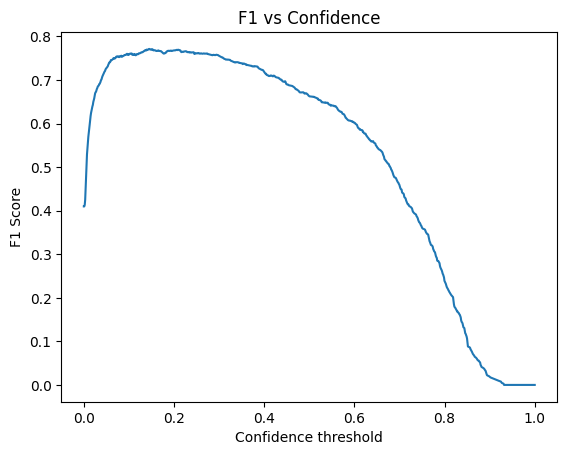

In [11]:
plt.plot(conf_thresholds, f1_curve)
plt.xlabel("Confidence threshold")
plt.ylabel("F1 Score")
plt.title("F1 vs Confidence")
plt.show()

In [13]:
threshold = 0.14514514514514515 # threshold calculado

In [14]:
# Predição das imagens de teste para avaliação visual e entendimento do modeo
folder_path = "/kaggle/input/datasets/nicodenico/microscopia/dataset/images/Test"

model.predict(
    folder_path, 
    conf = threshold,
    save=True, 
    show_labels=False,  
    show_conf=False,
)


image 1/10 /kaggle/input/datasets/nicodenico/microscopia/dataset/images/Test/HETMDB30_Spot1_1_nivelado_classified.png: 768x1024 52 mono_flakess, 66.9ms
image 2/10 /kaggle/input/datasets/nicodenico/microscopia/dataset/images/Test/HETMDB30_Spot5_3_nivelado_classified.png: 768x1024 111 mono_flakess, 13.7ms
image 3/10 /kaggle/input/datasets/nicodenico/microscopia/dataset/images/Test/HETMDB30_Spot5_4_nivelado_classified.png: 768x1024 127 mono_flakess, 13.8ms
image 4/10 /kaggle/input/datasets/nicodenico/microscopia/dataset/images/Test/HETMDB30_Spot5_8_nivelado_classified.png: 768x1024 109 mono_flakess, 13.8ms
image 5/10 /kaggle/input/datasets/nicodenico/microscopia/dataset/images/Test/HETMDB30_Spot5_9_nivelado_classified.png: 768x1024 124 mono_flakess, 12.8ms
image 6/10 /kaggle/input/datasets/nicodenico/microscopia/dataset/images/Test/HETMDB30_Spot6_6_nivelado_classified.png: 768x1024 77 mono_flakess, 12.8ms
image 7/10 /kaggle/input/datasets/nicodenico/microscopia/dataset/images/Test/HETMDB

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'mono_flakes'}
 obb: None
 orig_img: array([[[200, 200, 200],
         [200, 200, 200],
         [200, 200, 200],
         ...,
         [200, 200, 200],
         [200, 200, 200],
         [200, 200, 200]],
 
        [[200, 200, 200],
         [200, 200, 200],
         [200, 200, 200],
         ...,
         [200, 200, 200],
         [200, 200, 200],
         [200, 200, 200]],
 
        [[200, 200, 200],
         [200, 200, 200],
         [200, 200, 200],
         ...,
         [200, 200, 200],
         [200, 200, 200],
         [200, 200, 200]],
 
        ...,
 
        [[  0,   0, 255],
         [  0,   0, 255],
         [  0,   0, 255],
         ...,
         [  0, 255,   0],
         [  0, 255,   0],
         [  0, 255,   0]],
 
        [[  0,   0, 255],
         [  0,   0, 255],
         [  0,   0

In [15]:
metrics = model.val(
    data="dataset_teste.yaml",
    imgsz= 1920,
    conf= threshold,
    plots= True
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
val: Fast image access ✅ (ping: 0.7±0.2 ms, read: 108.0±35.5 MB/s, size: 51.0 KB)
val: Scanning /kaggle/input/datasets/nicodenico/microscopia/dataset/labels/Test... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 314.4it/s 0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/nicodenico/microscopia/dataset/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.5s/it 3.5s
                   all         10        802      0.757      0.787      0.803      0.695      0.753      0.783      0.801      0.605
Speed: 12.9ms preprocess, 39.3ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to /kaggle/working/runs/segment/val3


In [17]:
shutil.make_archive("resultados", "zip", "/kaggle/working/runs/segment/predict4")
shutil.make_archive("resultados_metricas", "zip", "/kaggle/working/runs/segment/val3")

'/kaggle/working/resultados_metricas.zip'

In [ ]:
# Deleta a pasta working para limpar a memória do Kaggle notebook (PERIGOSO!!)
!rm -rf /kaggle/working/*